In [71]:
from groq_llm import get_groq_llm
from langchain.messages import HumanMessage, AIMessage
from typing import TypedDict, List
from langgraph.graph import StateGraph, START, END

import json

In [130]:
class LegalSchema(TypedDict):
    query: str
    tools: List[str] = ["get_legal_context", "get_user_files_context", "get_web_context"]
    get_legal_context: str
    get_web_context: str
    get_user_files_context: str
    final_answer: str

In [131]:
llm = get_groq_llm()

In [132]:
#llm.invoke([HumanMessage("Hello how are you?")]).content

In [133]:
def route_query(state: dict):
    query = state["query"]

    prompt = f"""
You are a legal AI routing engine.

You MUST return ONLY valid JSON.

Schema:

  "tools": ["get_legal_context", "get_user_files_context", "get_web_context"]
  
Rules:
- Output ONLY JSON
- No markdown
- No explanation

User Query:
{query}
"""

    response = llm.invoke(prompt)
    
    return json.loads(response.content)   

In [134]:
res = route_query({"query": "What is the statute of limitations for a breach of contract in California?"})

In [136]:
res

{'tools': ['get_legal_context']}

In [78]:
# True if 'legal_rag' in res["tools"] else False

In [ ]:
from tools.ppc_rag_pipeline import rag_context_collector
from tools.web_search import run_web_search


def get_legal_context(state: LegalSchema) -> LegalSchema:

    query = state["query"]
    
    context = rag_context_collector(query)
    
    return {"get_legal_context": context}

def get_user_files_context(state: LegalSchema) -> LegalSchema:
    user_id = 1 
    query = state["query"]
    context = get_user_files_context(query, user_id, n_results=5)
    return {"get_user_files_context": context}

def get_web_context(state: LegalSchema) -> LegalSchema:
    
    query = state["query"]
    results = run_web_search(query)
    
    return {"get_web_context": results}

def merge_contexts(state: LegalSchema):
    return {
        "get_legal_context": state["get_legal_context"],
        "get_web_context": state["get_web_context"],
        "get_user_files_context": state["get_user_files_context"]
    }

def generate_answer(state: LegalSchema) -> LegalSchema:
    
    llm = get_groq_llm()
    context_dict = {
    "get_legal_context": state["get_legal_context"],
    "get_web_context": state["get_web_context"],
    "get_user_files_context": state["get_user_files_context"]
}

    prompt = """
    Here the collected context from various tools:
    {context_dict}
    You are a legal AI assistant. Use the above context to answer the user's {{"query": {query}}}
    Also if web is used then Give source urls in your answer.
    """.format(context_dict=context_dict, query=state["query"])

    response = llm.invoke(prompt)
    
    return {"final_answer": response.content}

In [138]:
def conditioner(state: LegalSchema) -> List[str]:
    tools = state['tools']

    routes = []

    if 'get_legal_context' in tools:
        routes.append('get_legal_context')
    if 'get_user_files_context' in tools:
        routes.append('get_user_files_context')
    if 'get_web_context' in tools:
        routes.append('get_web_context')
        
    return routes

In [139]:
graph = StateGraph(LegalSchema)

graph.add_node("route_query", route_query)
graph.add_node("get_user_files_context", get_user_files_context)
graph.add_node("get_legal_context", get_legal_context)
graph.add_node("get_web_context", get_web_context)
graph.add_node("generate_answer", generate_answer)
graph.add_node("merge_contexts", merge_contexts)


graph.add_edge(START, "route_query")
graph.add_conditional_edges("route_query", conditioner, {
    "get_legal_context": "get_legal_context",
    "get_user_files_context": "get_user_files_context",
    "get_web_context": "get_web_context"
})
graph.add_edge("get_legal_context", "merge_contexts")
graph.add_edge("get_user_files_context", "merge_contexts")
graph.add_edge("get_web_context", "merge_contexts")

graph.add_edge("merge_contexts", "generate_answer")
graph.add_edge("generate_answer", END)

gf = graph.compile()

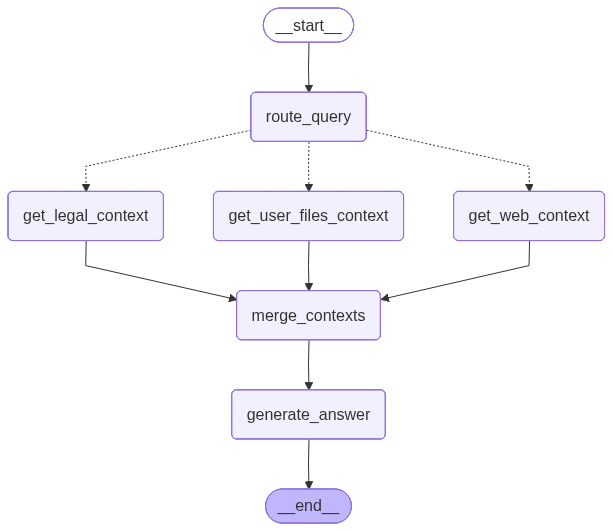

In [140]:
### Show graph structure using ipython
gf


In [141]:
initial_state = {
    "query": "what is punishment for Qatl acc to ppc also check web?",
    "get_legal_context": "",
    "get_web_context": "",
    "get_user_files_context": "",
    "final_answer": ""
}

In [142]:
response = gf.invoke(initial_state)

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 1807.03it/s]


In [143]:
response

{'query': 'what is punishment for Qatl acc to ppc also check web?',
 'tools': ['get_legal_context', 'get_web_context'],
 'get_legal_context': "Document: 319. Punishment for qatl-i-khata Whoever commits qatl-i-khata shall be liable to diyat: Provided that, where qatl-i-khata is committed by a rash or negligent act, other than rash or negligent driving, the offender may, in addition to diyat, also be punished with imprisonment of either description for a term which may extend to five years as ta'zir.\nMetadata: {'title': '319. Punishment for qatl-i-khata'}\n\nDocument: 324. Attempt to commit qatl-i-amd - Whoever does any act with such intention or knowledge, and under such circumstances, that, if he by that act caused qatl, he would be guilty of qatl-i-amd, shall be punished with imprisonment for either description for a term which may extend to ten years but shall not be less than five years if the offence has been committed in the name or on the pretext - of honour] and shall also be l

In [144]:
from IPython.display import Markdown, display
display(Markdown(response["final_answer"]))

**Punishment for “Qatl” (killing) under the Pakistan Penal Code 1860 (PPC)**  

| Kind of Qatl | Statutory provision (PPC) | Minimum / Maximum penalty | Additional consequences |
|--------------|---------------------------|---------------------------|--------------------------|
| **Qatl‑i‑khata** (unintentional / accidental killing) | **Section 319** – “Punishment for qatl‑i‑khata” | • Diyāt (blood‑money compensation) + imprisonment **up to 5 years** (as *taʿzīr*) when the act is rash or negligent **but not** a driving offence. | The offender must pay diyāt to the heirs of the deceased. |
| **Qatl‑i‑khata by rash or negligent driving** | **Section 320** – “Punishment for qatl‑i‑khata by rash or negligent driving” | • Diyāt + imprisonment **up to 10 years** (as *taʿzīr*). | Same diyāt liability; the longer term reflects the higher danger of reckless driving. |
| **Qatl‑i‑amd** (premeditated / intentional murder) | **Section 324** – “Attempt to commit qatl‑i‑amd” (the substantive offence is covered in Section 302, but the attempt is in 324) | • Imprisonment **5 – 10 years** (minimum 5 years, maximum 10 years).<br>• Fine (as prescribed). | If the act also causes hurt, the offender is liable for the punishment for that hurt (e.g., *qisas* or *arsh*). |
| **Attempt to commit qatl‑i‑amd** | **Section 324** (explicitly) | • Imprisonment **5 – 10 years** (minimum 5 years).<br>• Fine. | Same additional liability for any hurt caused. |
| **Qatl‑i‑shibh‑i‑amd** (killing with intent to harm but not likely to cause death) – mentioned in secondary sources | Not in the excerpted statutes, but commonly treated as *taʿzīr* (discretionary punishment). | • Diyāt **plus** imprisonment **up to 25 years** (per secondary literature). | Compensation plus long term imprisonment. |

### How the web sources describe the punishment

| Web source | Summary of punishment mentioned |
|------------|---------------------------------|
| **Scribd – “Types and Punishments of Qatl in PPC”** | “Qatl‑i‑Shibh‑i‑Amd … punishable by diyāt (compensation) and up to **25 years imprisonment**.” |
| **Studocu – Quiz on Qatl** | “Punishment for committing Qatl under Section 316 includes diyāt and imprisonment **up to 14 years** as *taʿzīr*.” |
| **Facebook discussion (unofficial)** | “Death or imprisonment for life as *taʿzīr*; imprisonment **up to 25 years** when qisas is not applicable.” |
| **PLJ Law Site (2009 article)** | “Qatl‑i‑amd is punishable as *qisas*; if the evidential standard is not met, punishment as *taʿzīr* **up to 25 years imprisonment**.” |
| **Quizlet – PPC Chapter 16** | Confirms that the attempt to Qatl‑i‑amd is covered by **Section 324** (answer C). |

**Sources (URLs)**  

1. Scribd – *Types and Punishments of Qatl in PPC* – <https://www.scribd.com/document/499700579/qatal>  
2. Studocu – *Quiz: Qatl and its kinds* – <https://www.studocu.com/row/quiz/qatl-and-its-kinds-hello/1970398>  
3. Facebook group post – *What is punishment for qatl under ppc 1860?* – <https://www.facebook.com/groups/660425117675956/posts/2411825152535935>  
4. PLJ Law Site – *Articles 2009* – <https://pljlawsite.com/2009art3.htm>  
5. Quizlet – *Pakistan Penal Code 1860 Chapter 16* – <https://quizlet.com/gb/772109680/pakistan-penal-code-1860-chapter-16-offences-affecting-human-bodypart-2-flash-cards>

### Bottom line

- **Unintentional killing (qatl‑i‑khata)** – diyāt + up to **5 years** (general) or up to **10 years** if caused by reckless driving.  
- **Premeditated killing (qatl‑i‑amd)** – *qisas* (death or retributive punishment) if the evidentiary standard is met; otherwise *taʿzīr* ranging **5 – 10 years** (or up to **25 years** in some commentaries).  
- **Attempts** are punished similarly, with a **minimum of 5 years** imprisonment and a fine.  

These figures combine the statutory language from the PPC (sections 319, 320, 324) with the additional ranges reported in publicly‑available web commentary.